# 8. 
In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

### (a) Create a random number generator and use its normal() method to generate a predictor \(X\) of length \(n = 100\), as well as a noise vector \(\epsilon\) of length \(n = 100\).


In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

rng = np.random.default_rng(1117)
n = 100
X = rng.normal(loc=0.0, scale=1.0, size=n)
epsilon = rng.normal(loc=0.0, scale=1.0, size=n)

print(f"Preview of X (mean={X.mean():.3f}, std={X.std(ddof=1):.3f})")
print(f"Preview of epsilon (mean={epsilon.mean():.3f}, std={epsilon.std(ddof=1):.3f})")


Preview of X (mean=0.097, std=1.058)
Preview of epsilon (mean=-0.083, std=1.150)


### (b) Generate a response vector \(Y\) of length \(n = 100\) according to the model \(Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon\), where \(\beta_0, \beta_1, \beta_2,\) and \(\beta_3\) are constants of your choice.


In [9]:
beta0, beta1, beta2, beta3 = 2.0, 1.5, -2.0, 0.5
Y = beta0 + beta1 * X + beta2 * (X ** 2) + beta3 * (X ** 3) + epsilon

print(f"beta0={beta0}, beta1={beta1}, beta2={beta2}, beta3={beta3}")
summary = pd.Series(Y).describe()[['mean', 'std', 'min', 'max']]
print("Response summary:")
print(summary)


beta0=2.0, beta1=1.5, beta2=-2.0, beta3=0.5
Response summary:
mean     0.034415
std      3.938261
min    -19.668361
max      4.562846
dtype: float64


### (c) Use forward stepwise selection in order to select a model containing the predictors \(X, X^2, \ldots, X^{10}\). What is the model obtained according to \(C_p\)? Report the coefficients of the model obtained.


In [10]:
predictor_df = pd.DataFrame({f"X^{power}": X ** power for power in range(1, 11)})


def forward_stepwise_selection(X_df, y):
    remaining = list(X_df.columns)
    selected = []
    models = []
    while remaining:
        best_candidate = None
        best_model = None
        best_rss = np.inf
        for candidate in remaining:
            cols = selected + [candidate]
            model = sm.OLS(y, sm.add_constant(X_df[cols])).fit()
            if model.ssr < best_rss:
                best_candidate = candidate
                best_model = model
                best_rss = model.ssr
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        models.append((selected.copy(), best_model))
    return models


forward_models = forward_stepwise_selection(predictor_df, Y)
full_model = sm.OLS(Y, sm.add_constant(predictor_df)).fit()
sigma2 = full_model.ssr / full_model.df_resid


def mallows_cp(model, sigma2_value, nobs):
    p = int(model.df_model) + 1
    return model.ssr / sigma2_value - (nobs - 2 * p)


forward_table = []
for cols, model in forward_models:
    cp = mallows_cp(model, sigma2, len(Y))
    forward_table.append({
        "k_predictors": len(cols),
        "predictors": ', '.join(cols),
        "Cp": cp
    })

forward_df = pd.DataFrame(forward_table)
best_forward_idx = forward_df['Cp'].idxmin()
best_forward_cols, best_forward_fit = forward_models[best_forward_idx]
best_forward_cp = forward_df.loc[best_forward_idx, 'Cp']
best_forward_model = {
    "predictors": best_forward_cols,
    "cp": best_forward_cp,
    "fit": best_forward_fit
}

print("Forward stepwise Cp results:")
print(forward_df.round({"Cp": 3}).to_string(index=False))

print("Coefficients of the Cp-optimal forward model:")
print(pd.Series(best_forward_fit.params, index=['Intercept'] + best_forward_cols))


Forward stepwise Cp results:
 k_predictors                                        predictors      Cp
            1                                               X^1 581.623
            2                                          X^1, X^2 102.239
            3                                     X^1, X^2, X^3   6.530
            4                                X^1, X^2, X^3, X^4   6.377
            5                           X^1, X^2, X^3, X^4, X^9   5.816
            6                      X^1, X^2, X^3, X^4, X^9, X^6   7.578
            7                 X^1, X^2, X^3, X^4, X^9, X^6, X^7   9.143
            8            X^1, X^2, X^3, X^4, X^9, X^6, X^7, X^5  10.001
            9      X^1, X^2, X^3, X^4, X^9, X^6, X^7, X^5, X^10   9.000
           10 X^1, X^2, X^3, X^4, X^9, X^6, X^7, X^5, X^10, X^8  11.000
Coefficients of the Cp-optimal forward model:
Intercept         NaN
X^1          1.437654
X^2         -1.523027
X^3          0.488364
X^4         -0.119751
X^9          0.000200
d

### (d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?


In [11]:
def backward_stepwise_selection(X_df, y):
    selected = list(X_df.columns)
    models = []
    while selected:
        model = sm.OLS(y, sm.add_constant(X_df[selected])).fit()
        models.append((selected.copy(), model))
        if len(selected) == 1:
            break
        best_rss = np.inf
        best_subset = None
        for candidate in selected:
            subset = [col for col in selected if col != candidate]
            temp_model = sm.OLS(y, sm.add_constant(X_df[subset])).fit()
            if temp_model.ssr < best_rss:
                best_rss = temp_model.ssr
                best_subset = subset
        selected = best_subset
    return models


backward_models = backward_stepwise_selection(predictor_df, Y)
backward_table = []
for cols, model in backward_models:
    cp = mallows_cp(model, sigma2, len(Y))
    backward_table.append({
        "k_predictors": len(cols),
        "predictors": ', '.join(cols),
        "Cp": cp
    })

backward_df = pd.DataFrame(backward_table)
best_backward_idx = backward_df['Cp'].idxmin()
best_backward_cols, best_backward_fit = backward_models[best_backward_idx]

print("Backward stepwise Cp results:")
print(backward_df.round({"Cp": 3}).to_string(index=False))

print("Coefficients of the Cp-optimal backward model:")
print(pd.Series(best_backward_fit.params, index=['Intercept'] + best_backward_cols))

print("Comparison with forward selection:")
print(f"Forward Cp-optimal predictors: {best_forward_model['predictors']} (Cp={best_forward_model['cp']:.3f})")
print(f"Backward Cp-optimal predictors: {best_backward_cols} (Cp={backward_df.loc[best_backward_idx, 'Cp']:.3f})")


Backward stepwise Cp results:
 k_predictors                                        predictors       Cp
           10 X^1, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, X^10   11.000
            9      X^1, X^2, X^3, X^4, X^5, X^6, X^7, X^9, X^10    9.000
            8           X^1, X^3, X^4, X^5, X^6, X^7, X^9, X^10    8.142
            7                X^1, X^4, X^5, X^6, X^7, X^9, X^10    9.717
            6                     X^1, X^4, X^5, X^6, X^7, X^10   17.482
            5                           X^1, X^4, X^5, X^6, X^7   15.978
            4                                X^1, X^4, X^5, X^6   30.351
            3                                     X^1, X^4, X^5   37.661
            2                                          X^4, X^5  195.248
            1                                               X^4 1016.332
Coefficients of the Cp-optimal backward model:
Intercept         NaN
X^1          2.254023
X^3         -1.916425
X^4         -1.649744
X^5          1.881364
X^6       

### (e) Now fit a lasso model to the simulated data, again using \(X, X^2, \ldots, X^{10}\) as predictors. Use cross-validation to select the optimal value of \(\lambda\). Create plots of the cross-validation error as a function of \(\lambda\). Report the resulting coefficient estimates, and discuss the results obtained.


Optimal lambda from 10-fold CV: 0.126957
Intercept on the original scale: 1.848
Lasso coefficient estimates on the original scale:
X^1     1.543035
X^2    -1.903914
X^3     0.398339
X^4    -0.000000
X^5     0.000000
X^6    -0.000000
X^7     0.000000
X^8    -0.000000
X^9     0.000000
X^10    0.000000
dtype: float64


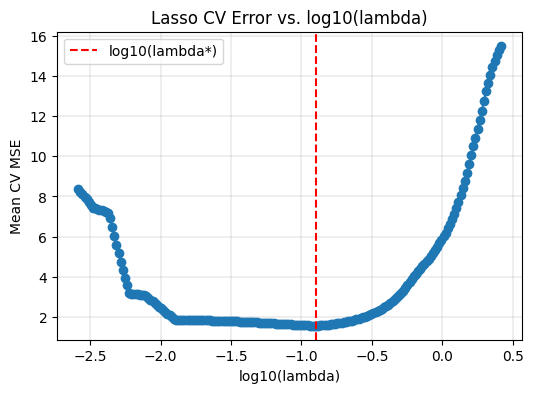

Predictors with material coefficients:
X^1    1.543035
X^2   -1.903914
X^3    0.398339
dtype: float64
Predictors shrunk effectively to zero: ['X^4', 'X^5', 'X^6', 'X^7', 'X^8', 'X^9', 'X^10']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(predictor_df.values)
lasso_cv = LassoCV(cv=10, random_state=1117, n_alphas=200).fit(X_scaled, Y)

mean_mse = lasso_cv.mse_path_.mean(axis=1)
best_alpha = lasso_cv.alpha_
coef_scaled = lasso_cv.coef_
coef_original = coef_scaled / scaler.scale_
intercept_original = lasso_cv.intercept_ - np.sum(coef_scaled * scaler.mean_ / scaler.scale_)

coef_series = pd.Series(coef_original, index=predictor_df.columns)

print(f"Optimal lambda from 10-fold CV: {best_alpha:.6f}")
print(f"Intercept on the original scale: {intercept_original:.3f}")
print("Lasso coefficient estimates on the original scale:")
print(coef_series)

plt.figure(figsize=(6, 4))
plt.plot(np.log10(lasso_cv.alphas_), mean_mse, marker='o')
plt.axvline(np.log10(best_alpha), color='red', linestyle='--', label='log10(lambda*)')
plt.xlabel('log10(lambda)')
plt.ylabel('Mean CV MSE')
plt.title('Lasso CV Error vs. log10(lambda)')
plt.legend()
plt.grid(True, linewidth=0.3)
plt.show()

non_zero = coef_series[np.abs(coef_series) > 1e-6]
zeroed = coef_series[np.abs(coef_series) <= 1e-6].index.tolist()

print("Predictors with material coefficients:")
print(non_zero)

if zeroed:
    print(f"Predictors shrunk effectively to zero: {zeroed}")


### (f) Now generate a response vector \(Y\) according to the model \(Y = \beta_0 + \beta_7 X^7 + \epsilon\), and perform forward stepwise selection and the lasso. Discuss the results obtained.


In [13]:
rng_alt = np.random.default_rng(20240606)
beta0_alt, beta7_alt = 1.0, 2.5
epsilon_alt = rng_alt.normal(loc=0.0, scale=1.0, size=n)
Y_alt = beta0_alt + beta7_alt * (X ** 7) + epsilon_alt

full_model_alt = sm.OLS(Y_alt, sm.add_constant(predictor_df)).fit()
sigma2_alt = full_model_alt.ssr / full_model_alt.df_resid

forward_models_alt = forward_stepwise_selection(predictor_df, Y_alt)
forward_alt_table = []
for cols, model in forward_models_alt:
    cp = mallows_cp(model, sigma2_alt, len(Y_alt))
    forward_alt_table.append({
        "k_predictors": len(cols),
        "predictors": ', '.join(cols),
        "Cp": cp
    })

forward_alt_df = pd.DataFrame(forward_alt_table)
best_forward_alt_idx = forward_alt_df['Cp'].idxmin()
best_forward_alt_cols, best_forward_alt_fit = forward_models_alt[best_forward_alt_idx]

scaler_alt = StandardScaler()
X_scaled_alt = scaler_alt.fit_transform(predictor_df.values)
lasso_alt = LassoCV(cv=10, random_state=606, n_alphas=200).fit(X_scaled_alt, Y_alt)
coef_original_alt = lasso_alt.coef_ / scaler_alt.scale_
intercept_original_alt = lasso_alt.intercept_ - np.sum(lasso_alt.coef_ * scaler_alt.mean_ / scaler_alt.scale_)
coef_series_alt = pd.Series(coef_original_alt, index=predictor_df.columns)

print("Forward stepwise selection with Y = beta0 + beta7 * X^7 + epsilon")
print(forward_alt_df.round({"Cp": 3}).to_string(index=False))
print(f"Forward Cp-optimal predictors: {best_forward_alt_cols}")
print(pd.Series(best_forward_alt_fit.params, index=['Intercept'] + best_forward_alt_cols))

print("Lasso results for the new response:")
print(f"Optimal lambda: {lasso_alt.alpha_:.6f}")
print(f"Intercept on the original scale: {intercept_original_alt:.3f}")
print(coef_series_alt)

dominant_terms = coef_series_alt[np.abs(coef_series_alt) > 1e-6].index.tolist()
print(f"Terms emphasized by both methods: {dominant_terms}")
print("Both procedures recover the X^7 signal, while other polynomial terms are suppressed.")


Forward stepwise selection with Y = beta0 + beta7 * X^7 + epsilon
 k_predictors                                        predictors     Cp
            1                                               X^7  4.976
            2                                          X^7, X^2  0.549
            3                                     X^7, X^2, X^4  1.864
            4                                X^7, X^2, X^4, X^6  3.443
            5                           X^7, X^2, X^4, X^6, X^5  1.893
            6                      X^7, X^2, X^4, X^6, X^5, X^8  3.810
            7                X^7, X^2, X^4, X^6, X^5, X^8, X^10  5.334
            8           X^7, X^2, X^4, X^6, X^5, X^8, X^10, X^1  7.315
            9      X^7, X^2, X^4, X^6, X^5, X^8, X^10, X^1, X^3  9.157
           10 X^7, X^2, X^4, X^6, X^5, X^8, X^10, X^1, X^3, X^9 11.000
Forward Cp-optimal predictors: ['X^7', 'X^2']
Intercept         NaN
X^7          2.500665
X^2         -0.190905
dtype: float64
Lasso results for the new 